In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
from tqdm import tqdm

## Задание 1.
**Проведите исследование того, как мощность T-test зависит от пропорций выборки.**
1) Для этого сгенерируйте выборку из 1000000 значений из нормального распределения со средний значением 100 и СКО 1000.
2) Далее разделите выборку в пропорции 50 на 50
3) Проведите синтетический AB тест, в котором группе B дайте разные размеры эффект (от 1% до 100% с шагом в 10%)
4) Посчитайте вероятность ошибки 2 рода
5) Повторите операции для выборок с пропорцией: 10 на 90, 20 на 80, 30 на 70, 40 на 60, где меньшее значение - это будет размер контрольной группы, а большее - размер тестовой группы
6) Постройте график, где по оси X будет размер эффекта, по оси Y вероятность ошибки 2 рода, а каждая линия соответсвует одной из пропорции

In [2]:
from scipy.stats import t as student_t

N_TOTAL = 1_000_000
MU = 100.0
SIGMA = 1000.0
ALPHA = 0.05   # двусторонний тест

EFFECTS = np.unique(np.concatenate([[0.01], np.arange(0.1, 1.0 + 1e-12, 0.1)])).round(2)

PROPORTIONS = [
    (0.5, 0.5,  "50/50"),
    (0.4, 0.6,  "40/60"),
    (0.3, 0.7,  "30/70"),
    (0.2, 0.8,  "20/80"),
    (0.1, 0.9,  "10/90"),
]

K_SPLITS = 200
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pool = rng.normal(loc=MU, scale=SIGMA, size=N_TOTAL).astype(np.float64, copy=False)
pool_sq = pool * pool
SUM_TOTAL = float(pool.sum())
SUMSQ_TOTAL = float(pool_sq.sum())

len(pool), pool.mean(), pool.std(ddof=1)

(1000000, np.float64(100.09750249789377), np.float64(1000.4831434820154))

In [3]:
#Считает несмещённую выборочную дисперсию по уже посчитанным суммам
def var_from_sums(n, s, s2):
    #var = (sum(x^2) - sum(x)^2 / n) / (n-1) - несложно вывести
    return (s2 - s*s / n) / (n - 1)

#Возвращает аппроксимацию Уэлча–Саттертуэйта для степеней свободы и квадрат стандартной ошибки разности средних в тесте Уэлча по дисперсиям и размерам выборок.
def welch_df_and_se2(v1, n1, v2, n2):
    se2 = v1 / n1 + v2 / n2
    num = se2**2
    den = (v1**2) / (n1**2 * (n1 - 1)) + (v2**2) / (n2**2 * (n2 - 1))
    df = num / den
    return df, se2

#Используем критерий Уэлча, поскольку возникает дисбаланс по размерам подвыборок A и B(его вроде можно использовать
#не только в случае неравных дисперсий, но и если размеры выборок различны)
def stats_for_split_indices(idx_a):
    n_a = idx_a.size
    n_b = N_TOTAL - n_a

    sum_a = float(pool[idx_a].sum())
    sumsq_a = float(pool_sq[idx_a].sum())
    mean_a = sum_a / n_a
    var_a = var_from_sums(n_a, sum_a, sumsq_a)

    sum_b = SUM_TOTAL - sum_a
    sumsq_b = SUMSQ_TOTAL - sumsq_a
    mean_b = sum_b / n_b
    var_b = var_from_sums(n_b, sum_b, sumsq_b)

    df, se2 = welch_df_and_se2(var_a, n_a, var_b, n_b)
    diff0 = mean_b - mean_a
    return diff0, se2, df, n_a, n_b

def collect_splits_for_proportion(p_ctrl, K, rng):
    n_a = int(round(N_TOTAL * p_ctrl))
    diff0 = np.empty(K, dtype=np.float64)
    se2 = np.empty(K, dtype=np.float64)
    df = np.empty(K, dtype=np.float64)

    for k in range(K):
        idx_a = rng.choice(N_TOTAL, size=n_a, replace=False)
        d0, s2, dff, _, _ = stats_for_split_indices(idx_a)
        diff0[k] = d0
        se2[k] = s2
        df[k] = dff
    return {"diff0": diff0, "se2": se2, "df": df}


In [4]:
precomputed = {}

for p_a, p_b, label in PROPORTIONS:
    precomputed[label] = collect_splits_for_proportion(p_a, K_SPLITS, rng)

{label: {k: v.shape for k, v in cache.items()} for label, cache in precomputed.items()}

{'50/50': {'diff0': (200,), 'se2': (200,), 'df': (200,)},
 '40/60': {'diff0': (200,), 'se2': (200,), 'df': (200,)},
 '30/70': {'diff0': (200,), 'se2': (200,), 'df': (200,)},
 '20/80': {'diff0': (200,), 'se2': (200,), 'df': (200,)},
 '10/90': {'diff0': (200,), 'se2': (200,), 'df': (200,)}}

In [5]:
beta_rows = []
for effect in EFFECTS:
    delta = MU * effect
    for _, _, label in PROPORTIONS:
        cache = precomputed[label]
        tvals = (cache["diff0"] + delta) / np.sqrt(cache["se2"])
        pvals = 2.0 * student_t.sf(np.abs(tvals), cache["df"])
        beta = float((pvals >= ALPHA).mean())
        beta_rows.append({"effect_percent": int(round(effect*100)), "split": label, "beta": beta})

df_beta = (
    pd.DataFrame(beta_rows)
    .pivot(index="effect_percent", columns="split", values="beta")
    .sort_index()
)
df_beta.round(4)


split,10/90,20/80,30/70,40/60,50/50
effect_percent,,,,,
1,0.93,0.905,0.935,0.905,0.935
10,0.15,0.020,0.000,0.010,0.000
20,0.00,0.000,0.000,0.000,0.000
30,0.00,0.000,0.000,0.000,0.000
40,0.00,0.000,0.000,0.000,0.000
50,0.00,0.000,0.000,0.000,0.000
60,0.00,0.000,0.000,0.000,0.000
70,0.00,0.000,0.000,0.000,0.000
80,0.00,0.000,0.000,0.000,0.000


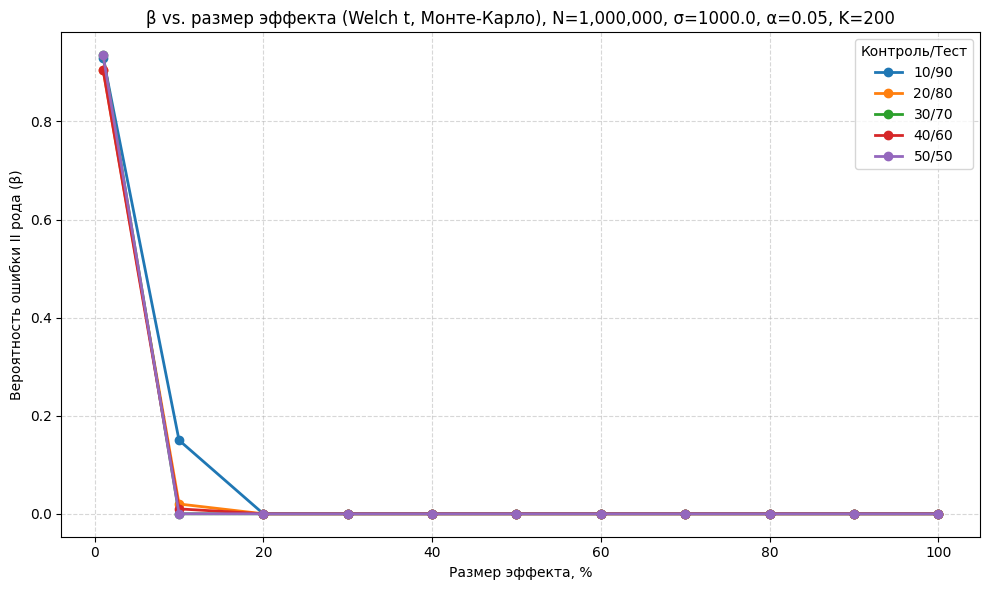

In [6]:
plt.figure(figsize=(10, 6))
x = df_beta.index.values
for label in df_beta.columns:
    plt.plot(x, df_beta[label].values, marker="o", linewidth=2, label=label)

plt.xlabel("Размер эффекта, %")
plt.ylabel("Вероятность ошибки II рода (β)")
plt.title(f"β vs. размер эффекта (Welch t, Монте-Карло), N={N_TOTAL:,}, σ={SIGMA}, α={ALPHA}, K={K_SPLITS}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Контроль/Тест")
plt.tight_layout()
plt.show()


Результаты получились закономерными: При N=$10^6$ стандартная ошибка разности средних очень мала, особенно при 50/50, поэтому уже при умеренных эффектах мощность ≈1 (а β≈0). Дисбаланс 10/90 увеличивает SE ⇒ мощность падает ⇒
β выше. Однако при увеличении размера эффекта ошибка второго рода всё же устремляется к 0.

## Задание 2.
**Подведение результатов эксперимента**
1) Откройте файл с данными `data_with_test_results.csv`
2) Посчитайте посчитайте количество заказов у каждого клиента за период эксперимента
3) Посчитайте насколько значимы изменения среднего количества заказов у клиента в группе B по сравнению с группой А с помощью t-теста и бутстрапа
4) Постройте график с кумулятивным среднийм значеним в группе A и B и посмотрите насколько этот эффект виден

In [7]:
PATH = "data_with_test_results.csv"

df = pd.read_csv(PATH)
df.head()

,Unnamed: 0,user_id,group,order_date,orders_cnt
0,0,1,A,2025-01-09,1
1,1,1,A,2025-01-12,3
2,2,1,A,2025-01-19,1
3,3,2,B,2025-01-02,1
4,4,2,B,2025-01-06,1


In [8]:
df['group'].unique()

array(['A', 'B'], dtype=object)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3414 entries, 0 to 3413
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  3414 non-null   int64 
 1   user_id     3414 non-null   int64 
 2   group       3414 non-null   object
 3   order_date  3414 non-null   object
 4   orders_cnt  3414 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 133.5+ KB


In [10]:
orders_per_user = (
    df.groupby(['group', 'user_id'])
      .size()
      .rename("orders_per_user")
      .reset_index()
)

a = orders_per_user.loc[orders_per_user['group']=="A","orders_per_user"].to_numpy()
b = orders_per_user.loc[orders_per_user['group']=="B","orders_per_user"].to_numpy()

print(f"A: n={a.size}, mean={a.mean():.4f}, std={a.std(ddof=1):.4f}")
print(f"B: n={b.size}, mean={b.mean():.4f}, std={b.std(ddof=1):.4f}")

#Критерий Уэлча
tt = ttest_ind(b, a, equal_var=False, alternative="two-sided")
print(f"Welch t-test: statistic={tt.statistic:.4f}, p-value={tt.pvalue:.6g}")

obs_diff = b.mean() - a.mean()
print(f"Разница средних (B - A) = {obs_diff:.6f}")

A: n=490, mean=3.4061, std=1.0646
B: n=510, mean=3.4216, std=1.1251
Welch t-test: statistic=0.2231, p-value=0.823534
Разница средних (B - A) = 0.015446


p-value=0.823534. Значит, при уровне значимости 5% нет оснований отвергать нулевую гипотезу(равенство средних).

In [11]:
def bootstrap_mean_diff(arr_a, arr_b, n_boot=20000, seed=42):
    rng = np.random.default_rng(seed)
    n_a, n_b = arr_a.size, arr_b.size
    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        sa = arr_a[rng.integers(0, n_a, size=n_a)]
        sb = arr_b[rng.integers(0, n_b, size=n_b)]
        diffs[i] = sb.mean() - sa.mean()
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    return diffs, (ci_low, ci_high)

diffs, (ci_l, ci_h) = bootstrap_mean_diff(a, b, n_boot=20000, seed=42)

print(f"95% ДИ для (B - A): [{ci_l:.6f}, {ci_h:.6f}]")

95% ДИ для (B - A): [-0.119208, 0.152905]


Ноль внутри ДИ, т.е. вывод совпадает с t-тестом.

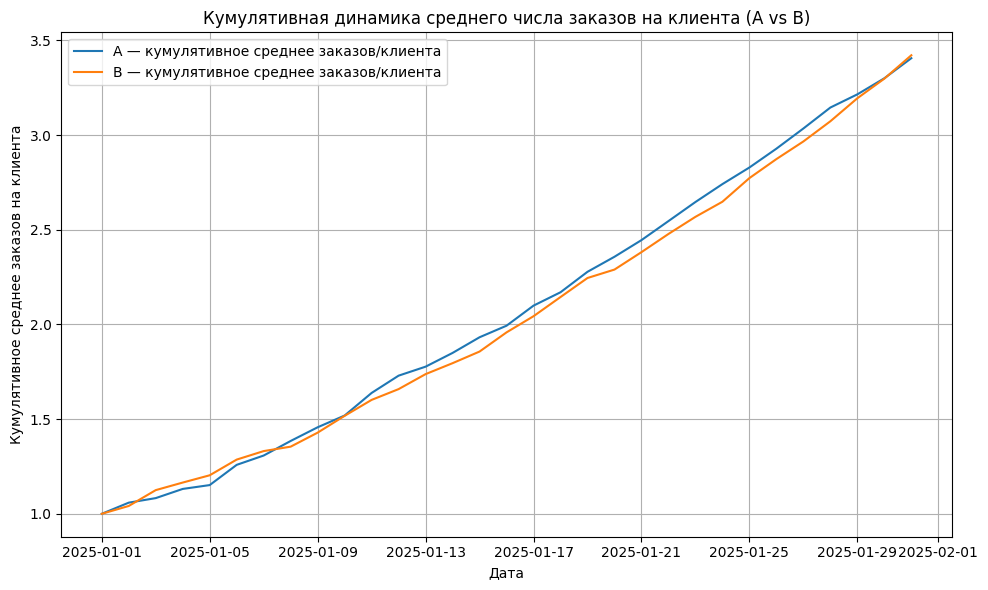

In [12]:
def cumulative_avg_by_group(frame, group_value):
    g = frame[frame['group'] == group_value].copy()
    g['order_date'] = pd.to_datetime(g['order_date'], errors="coerce")
    g['day'] = g['order_date'].dt.normalize()

    orders_per_day = g.groupby('day', observed=True).size().rename('orders_per_day')

    first_seen = g.groupby('user_id', observed=True)['day'].min()
    new_users_per_day = first_seen.value_counts().sort_index().rename('new_users')

    all_days = pd.date_range(g['day'].min(), g['day'].max(), freq="D")

    s_orders = orders_per_day.reindex(all_days, fill_value=0).sort_index()
    s_new    = new_users_per_day.reindex(all_days, fill_value=0).sort_index()

    cum_orders = s_orders.cumsum()
    cum_users  = s_new.cumsum()

    cum_avg = (cum_orders / cum_users.replace(0, np.nan)).rename(f"cum_avg_{group_value}")

    out = cum_avg.to_frame()
    out.index.name = 'date'
    return out

cumA = cumulative_avg_by_group(df, "A")
cumB = cumulative_avg_by_group(df, "B")
cum  = cumA.join(cumB, how="outer").sort_index()

plt.figure(figsize=(10, 6))
plt.plot(cum.index, cum["cum_avg_A"], label="A — кумулятивное среднее заказов/клиента")
plt.plot(cum.index, cum["cum_avg_B"], label="B — кумулятивное среднее заказов/клиента")
plt.ylabel("Кумулятивное среднее заказов на клиента")
plt.xlabel("Дата")
plt.title("Кумулятивная динамика среднего числа заказов на клиента (A vs B)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Эффект на кумулятивном графике практически не виден. Линии A и B почти совпадают на всём интервале; к концу периода разница кумулятивных средних B−A ≈ 0.015 заказа на клиента (≈ 0.45%), при этом Welch t-test: p=0.823 и бутстрап-ДИ [−0.119; 0.153] включает ноль. Следовательно, визуально заметных расхождений нет, и статистически значимого эффекта не обнаружено.

## Задание 3.
**Дизайн эксперимента**
1) Откройте файл с данными `dataset_for_design`
2) Рассчитайте количество наблюдений, которое необходимо набрать, чтобы у этой метрики увидеть ее увеличение на 5%
3) Проверьте свой ответ с помощью метода Монте-Карло. Покажите, что мощность теста действительно совпадает с заявленной



In [13]:
PATH = "dataset_for_design.csv"

df = pd.read_csv(PATH)
df.head()

,Unnamed: 0,user_id,total_orders
0,0,1,5.481016
1,1,2,3.514178
2,2,3,6.091976
3,3,4,11.242615
4,4,5,3.286040


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    1000 non-null   int64  
 1   user_id       1000 non-null   int64  
 2   total_orders  1000 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 23.6 KB


In [15]:
for col in df.columns:
    if col.lower().startswith("unnamed"):
        df = df.drop(columns=[col])
        break

df.head(), df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       1000 non-null   int64  
 1   total_orders  1000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 15.8 KB


(   user_id  total_orders
 0        1      5.481016
 1        2      3.514178
 2        3      6.091976
 3        4     11.242615
 4        5      3.286040,
 None)

Мы проверяем прирост среднего на +5% и моделируем эффект как аддитивный сдвиг +δ без изменения дисперсии. При фиксированном общем N и равных дисперсиях мощность максимальна при n_A=n_B.

Эквивалентно: для заданных α и мощности минимальный требуемый N получается именно при 50/50.

In [16]:
from scipy.stats import norm
import math

ALPHA = 0.05       # уровень значимости
POWER = 0.80       # целевая мощность (1 - beta)
UPLIFT = 0.05      # эффект среднего +5%

metric = df['total_orders'].to_numpy(dtype=float)
mu = metric.mean()
sd = metric.std(ddof=1)
delta = UPLIFT * mu

z_alpha = norm.ppf(1 - ALPHA/2)
z_beta  = norm.ppf(POWER)

n_per_group = math.ceil( 2 * ((z_alpha + z_beta) * sd / delta)**2 )
n_total = 2 * n_per_group

print(f"Базовые оценки: μ={mu:.6f}, σ={sd:.6f}")
print(f"Целевой сдвиг δ = 0.05·μ = {delta:.6f}")
print(f"Требуемый размер для 50/50 и Welch t: n_per_group ≈ {n_per_group:,}, n_total ≈ {n_total:,}")


Базовые оценки: μ=5.000727, σ=4.134294
Целевой сдвиг δ = 0.05·μ = 0.250036
Требуемый размер для 50/50 и Welch t: n_per_group ≈ 4,292, n_total ≈ 8,584


In [17]:
RNG = np.random.default_rng(42)
N_TRIALS = 3000

def mc_power(n_per_group, trials=N_TRIALS, alpha=ALPHA, seed=42):
    rng = np.random.default_rng(seed)
    n = n_per_group
    rejections = 0
    for _ in range(trials):
        a = metric[rng.integers(0, metric.size, size=n)]
        b = metric[rng.integers(0, metric.size, size=n)] + delta
        #Критерий Уэлча
        tt = ttest_ind(b, a, equal_var=False, alternative="two-sided")
        if tt.pvalue < alpha:
            rejections += 1
    return rejections / trials

emp_power = mc_power(n_per_group)
print(f"Эмпирическая мощность при n_per_group={n_per_group:,}: {emp_power:.3f} (цель {POWER:.2f})")

Эмпирическая мощность при n_per_group=4,292: 0.807 (цель 0.80)


Выбранный размер выборки обеспечивает требуемую мощность для обнаружения роста среднего числа заказов на пользователя на
5% — расчёт и Монте-Карло согласуются.